<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/main/notebooks/13_Primary_Models_vs_Rolling30_Volatility_Proxy_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13 — Final Proxy-Based Robustness Evaluation

This notebook performs the supervisor-requested final robustness check.

It **does not retrain any DL or ARCH model**.

Instead, the already-frozen one-day-ahead variance forecasts are compared with an alternative observable volatility proxy:

\[
HV_{30,t}
=
\operatorname{Std}
\left(
r_{t-29},\ldots,r_t
\right)
\]

using 30 consecutive daily log returns and sample standard deviation (`ddof=1`).

For each target date \(t\):

- model variance forecast: \(\hat{\sigma}_t^2\)
- model volatility forecast for plotting / MAE / RMSE:

\[
\hat{\sigma}_t
=
\sqrt{\hat{\sigma}_t^2}
\]

- historical-volatility proxy:

\[
HV_{30,t}
\]

- QLIKE is calculated on the variance scale:

\[
HV_{30,t}^2
\quad \text{vs} \quad
\hat{\sigma}_t^2.
\]

## Models included in the final comparison

Only the forecasting models are retained:

### ARCH family
- GARCH(1,1)
- GJR-GARCH(1,1)
- EGARCH(1,1)

### Deep learning
- MLP 30D
- GRU 7D
- LSTM 14D

Persistence, 7-Day Mean RV and 30-Day Mean RV are deliberately excluded from the final tables and figures.

## Important interpretation

The 30-day historical-volatility proxy for target date \(t\) includes the realized return on date \(t\). It is therefore an **ex-post volatility proxy**, not a one-step-ahead predictive baseline.

## 1. Imports, paths and configuration

In [1]:
from google.colab import drive
from pathlib import Path

import importlib.util
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if importlib.util.find_spec("arch") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "arch",
        ]
    )

from arch import arch_model

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

DAILY_FEATURE_PATH = (
    PROJECT_DIR
    / "data"
    / "model_ready"
    / "crypto_daily_features_v1.parquet"
)

OUTPUT_DIR = (
    RESULTS_DIR
    / "ROLLING30_PROXY_EVALUATION_FINAL"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

ASSET_LABELS = {
    "BTCUSDT": "BTC",
    "ETHUSDT": "ETH",
    "SOLUSDT": "SOL",
    "XRPUSDT": "XRP",
}

TRAIN_END = pd.Timestamp(
    "2024-07-31",
    tz="UTC",
)

VALIDATION_START = pd.Timestamp(
    "2024-08-01",
    tz="UTC",
)

VALIDATION_END = pd.Timestamp(
    "2025-07-31",
    tz="UTC",
)

ROLLING_WINDOW = 30
ROLLING_DDOF = 1
RETURN_SCALE = 100.0
EPSILON = 1e-12
MIN_TRAIN_OBS = 100

MODEL_LOOKBACKS = {
    "MLP": 30,
    "GRU": 7,
    "LSTM": 14,
}

DISPLAY_MODEL_MAP = {
    "GARCH(1,1)": "GARCH (1,1)",
    "GJR-GARCH(1,1)": "GJR-GARCH (1,1)",
    "EGARCH(1,1)": "EGARCH (1,1)",
    "Global-MLP-30d": "MLP 30D",
    "Global-GRU-7d": "GRU 7D",
    "Global-LSTM-14d": "LSTM 14D",
}

MODEL_COLUMN_ORDER = [
    "GARCH (1,1)",
    "GJR-GARCH (1,1)",
    "EGARCH (1,1)",
    "MLP 30D",
    "GRU 7D",
    "LSTM 14D",
]

print("Input:", DAILY_FEATURE_PATH)
print("Output:", OUTPUT_DIR)

Mounted at /content/drive
Input: /content/drive/MyDrive/Quant Research/data/model_ready/crypto_daily_features_v1.parquet
Output: /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL


## 2. Load and validate the primary daily feature dataset

In [2]:
if not DAILY_FEATURE_PATH.exists():
    raise FileNotFoundError(
        "Primary daily feature file not found:\n"
        f"{DAILY_FEATURE_PATH}"
    )

daily_df = pd.read_parquet(
    DAILY_FEATURE_PATH
)

required_columns = {
    "symbol",
    "date",
    "daily_return",
    "realized_variance",
    "rv_mean_30d",
}

missing_columns = (
    required_columns
    - set(
        daily_df.columns
    )
)

if missing_columns:
    raise ValueError(
        "Primary daily feature file "
        f"is missing: {missing_columns}"
    )

daily_df["date"] = pd.to_datetime(
    daily_df["date"],
    utc=True,
    errors="raise",
)

daily_df = (
    daily_df.loc[
        daily_df[
            "symbol"
        ].isin(ASSETS)
    ]
    .sort_values(
        [
            "symbol",
            "date",
        ]
    )
    .drop_duplicates(
        [
            "symbol",
            "date",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

if daily_df.duplicated(
    subset=[
        "symbol",
        "date",
    ]
).any():
    raise ValueError(
        "Duplicate symbol-date rows remain."
    )

display(
    daily_df
    .groupby("symbol")
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        rows=("date", "size"),
        valid_returns=("daily_return", "count"),
    )
)

,first_date,last_date,rows,valid_returns
symbol,,,,
BTCUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3271
ETHUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272,3271
SOLUSDT,2020-08-11 00:00:00+00:00,2026-08-01 00:00:00+00:00,2182,2181
XRPUSDT,2018-05-04 00:00:00+00:00,2026-08-01 00:00:00+00:00,3012,3011


## 3. Construct the 30-day historical-volatility proxy

For each date \(t\), the proxy uses the 30 daily returns ending on \(t\):

\[
r_{t-29},\ldots,r_t.
\]

A valid proxy observation requires 30 consecutive calendar-day returns.

In [3]:
proxy_frames = []

for symbol in ASSETS:

    asset_df = (
        daily_df.loc[
            daily_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    rolling_returns = (
        asset_df[
            "daily_return"
        ]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
    )

    asset_df[
        "rolling30_mean_return"
    ] = rolling_returns.mean()

    asset_df[
        "rolling30_mean_r2"
    ] = (
        asset_df[
            "realized_variance"
        ]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .mean()
    )

    asset_df[
        "rolling30_vol_proxy"
    ] = rolling_returns.std(
        ddof=ROLLING_DDOF
    )

    asset_df[
        "rolling30_window_start"
    ] = (
        asset_df[
            "date"
        ]
        .shift(
            ROLLING_WINDOW - 1
        )
    )

    date_span_ok = (
        (
            asset_df["date"]
            - asset_df[
                "rolling30_window_start"
            ]
        )
        == pd.Timedelta(
            days=ROLLING_WINDOW - 1
        )
    )

    adjacent_day_ok = (
        asset_df[
            "date"
        ]
        .diff()
        .eq(
            pd.Timedelta(days=1)
        )
        .rolling(
            window=ROLLING_WINDOW - 1,
            min_periods=ROLLING_WINDOW - 1,
        )
        .sum()
        .eq(
            ROLLING_WINDOW - 1
        )
    )

    valid_window = (
        date_span_ok
        & adjacent_day_ok
        & rolling_returns.count().eq(
            ROLLING_WINDOW
        )
    )

    columns_to_mask = [
        "rolling30_mean_return",
        "rolling30_mean_r2",
        "rolling30_vol_proxy",
    ]

    asset_df.loc[
        ~valid_window,
        columns_to_mask,
    ] = np.nan

    asset_df[
        "rolling30_var_proxy"
    ] = (
        asset_df[
            "rolling30_vol_proxy"
        ] ** 2
    )

    proxy_frames.append(
        asset_df
    )


daily_proxy_df = (
    pd.concat(
        proxy_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "symbol",
            "date",
        ]
    )
    .reset_index(drop=True)
)


proxy_df = (
    daily_proxy_df.loc[
        daily_proxy_df[
            "date"
        ].between(
            VALIDATION_START,
            VALIDATION_END,
        ),
        [
            "symbol",
            "date",
            "rolling30_vol_proxy",
            "rolling30_var_proxy",
        ],
    ]
    .rename(
        columns={
            "date": "target_date"
        }
    )
    .dropna()
    .reset_index(drop=True)
)


proxy_summary_df = (
    proxy_df
    .groupby("symbol")
    .agg(
        observations=("target_date", "size"),
        first_target=("target_date", "min"),
        last_target=("target_date", "max"),
        mean_volatility=("rolling30_vol_proxy", "mean"),
    )
)

display(proxy_summary_df)

assert (
    proxy_summary_df[
        "observations"
    ]
    == 365
).all()

assert (
    proxy_summary_df[
        "first_target"
    ]
    == VALIDATION_START
).all()

assert (
    proxy_summary_df[
        "last_target"
    ]
    == VALIDATION_END
).all()

assert (
    proxy_df[
        "rolling30_vol_proxy"
    ]
    > 0
).all()

print(
    "Rolling-30 proxy QC passed."
)

,observations,first_target,last_target,mean_volatility
symbol,,,,
BTCUSDT,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00,0.024391
ETHUSDT,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00,0.037542
SOLUSDT,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00,0.042947
XRPUSDT,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00,0.045219


Rolling-30 proxy QC passed.


## 4. Why this is different from `30-Day Mean RV`

The two statistics can use the **same 30 dates** and still be different.

### 30-Day Mean RV

Because daily realized variance is \(r_t^2\),

\[
RVMean30_t
=
\frac{1}{30}
\sum_{i=t-29}^{t}
r_i^2.
\]

This is the rolling **second moment** of returns.

### 30-Day Historical Volatility

\[
HV_{30,t}
=
\sqrt{
\frac{1}{29}
\sum_{i=t-29}^{t}
(r_i-\bar r)^2
}.
\]

This is the sample standard deviation around the rolling mean return.

Equivalently,

\[
HV^2_{30,t}
=
\frac{30}{29}
\left(
RVMean30_t-\bar r_t^2
\right).
\]

Therefore they are closely related when the rolling mean return is small, but they are not mathematically identical.

### Timing distinction

If both statistics are computed **for 10 August itself**, both can use data through 10 August.

However, the earlier predictive `30-Day Mean RV` baseline for a **10 August forecast** used the value available at the forecast origin on 9 August. In that forecasting setup its 30-day window ends on 9 August.

The historical-volatility proxy used in this notebook is an ex-post reference for 10 August and therefore includes the realized 10 August return.

In [4]:
relation_df = (
    daily_proxy_df.loc[
        daily_proxy_df[
            "rolling30_var_proxy"
        ].notna(),
        [
            "symbol",
            "date",
            "rv_mean_30d",
            "rolling30_mean_r2",
            "rolling30_mean_return",
            "rolling30_var_proxy",
            "rolling30_vol_proxy",
        ],
    ]
    .copy()
)

relation_df[
    "sample_variance_from_moments"
] = (
    ROLLING_WINDOW
    / (
        ROLLING_WINDOW - 1
    )
) * (
    relation_df[
        "rolling30_mean_r2"
    ]
    - (
        relation_df[
            "rolling30_mean_return"
        ] ** 2
    )
)

relation_df[
    "sqrt_rv_mean_30d"
] = np.sqrt(
    np.maximum(
        relation_df[
            "rv_mean_30d"
        ].to_numpy(
            dtype=float
        ),
        0.0,
    )
)

identity_error = float(
    np.nanmax(
        np.abs(
            relation_df[
                "sample_variance_from_moments"
            ]
            - relation_df[
                "rolling30_var_proxy"
            ]
        )
    )
)

relationship_rows = []

for symbol in ASSETS:

    current = (
        relation_df.loc[
            relation_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    relationship_rows.append({
        "asset": ASSET_LABELS[symbol],
        "correlation_sqrt_mean_rv30_vs_hist_vol":
            float(
                current[
                    [
                        "sqrt_rv_mean_30d",
                        "rolling30_vol_proxy",
                    ]
                ]
                .corr()
                .iloc[0, 1]
            ),
        "mean_abs_difference":
            float(
                np.mean(
                    np.abs(
                        current[
                            "sqrt_rv_mean_30d"
                        ]
                        - current[
                            "rolling30_vol_proxy"
                        ]
                    )
                )
            ),
    })

relationship_df = pd.DataFrame(
    relationship_rows
)

print(
    "Max sample-variance identity error:",
    identity_error,
)

display(
    relationship_df.style.format({
        "correlation_sqrt_mean_rv30_vs_hist_vol":
            "{:.6f}",
        "mean_abs_difference":
            "{:.8f}",
    })
)

assert identity_error < 1e-12

Max sample-variance identity error: 3.469446951953614e-17


,asset,correlation_sqrt_mean_rv30_vs_hist_vol,mean_abs_difference
0,BTC,0.998112,0.00057926
1,ETH,0.997990,0.00073506
2,SOL,0.997336,0.00102660
3,XRP,0.998664,0.00066800


# Part A — Frozen model forecasts

## 5. Load selected Global DL forecasts

In [5]:
global_prediction_frames = []

for (
    architecture,
    lookback_days,
) in MODEL_LOOKBACKS.items():

    prediction_path = (
        RESULTS_DIR
        / "GLOBAL_4_ASSETS"
        / f"lookback_{lookback_days}d"
        / architecture
        / "validation_predictions.parquet"
    )

    if not prediction_path.exists():
        raise FileNotFoundError(
            "Missing Global DL prediction file:\n"
            f"{prediction_path}"
        )

    current = pd.read_parquet(
        prediction_path
    )

    required = {
        "symbol",
        "target_date",
        "pred_rv",
    }

    missing = (
        required
        - set(
            current.columns
        )
    )

    if missing:
        raise ValueError(
            f"{prediction_path} "
            f"is missing {missing}"
        )

    current[
        "target_date"
    ] = pd.to_datetime(
        current[
            "target_date"
        ],
        utc=True,
        errors="raise",
    )

    model_label = (
        f"Global-{architecture}-"
        f"{lookback_days}d"
    )

    current = (
        current.loc[
            current[
                "symbol"
            ].isin(ASSETS)
            & current[
                "target_date"
            ].between(
                VALIDATION_START,
                VALIDATION_END,
            ),
            [
                "symbol",
                "target_date",
                "pred_rv",
            ],
        ]
        .copy()
    )

    current[
        "pred_rv"
    ] = pd.to_numeric(
        current[
            "pred_rv"
        ],
        errors="coerce",
    )

    current[
        "model"
    ] = model_label

    current[
        "display_model"
    ] = (
        DISPLAY_MODEL_MAP[
            model_label
        ]
    )

    current[
        "model_family"
    ] = "Deep Learning"

    global_prediction_frames.append(
        current
    )


global_predictions_df = (
    pd.concat(
        global_prediction_frames,
        ignore_index=True,
    )
    .dropna(
        subset=[
            "pred_rv"
        ]
    )
)

global_counts = (
    global_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=("target_date", "size"),
        first_date=("target_date", "min"),
        last_date=("target_date", "max"),
    )
    .reset_index()
)

display(global_counts)

assert (
    len(global_counts)
    == (
        len(ASSETS)
        * len(
            MODEL_LOOKBACKS
        )
    )
)

assert (
    global_counts[
        "observations"
    ]
    == 365
).all()

assert (
    global_counts[
        "first_date"
    ]
    == VALIDATION_START
).all()

assert (
    global_counts[
        "last_date"
    ]
    == VALIDATION_END
).all()

print(
    "Global DL forecast QC passed."
)

,symbol,model,observations,first_date,last_date
0,BTCUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
1,BTCUSDT,Global-LSTM-14d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
2,BTCUSDT,Global-MLP-30d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
3,ETHUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
4,ETHUSDT,Global-LSTM-14d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
5,ETHUSDT,Global-MLP-30d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
6,SOLUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
7,SOLUSDT,Global-LSTM-14d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
8,SOLUSDT,Global-MLP-30d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
9,XRPUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00


Global DL forecast QC passed.


## 6. Reproduce the frozen ARCH validation forecasts

The ARCH forecasts are reproduced directly from the finalized daily-return series.

This avoids any dependence on older partial saved prediction artifacts.

Methodology remains unchanged:

1. fit parameters on training returns through 2024-07-31;
2. keep parameters fixed;
3. use realized validation returns to update the conditional state;
4. produce one-step-ahead variance forecasts for all 365 validation dates.

In [6]:
ARCH_SPECS = {
    "GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
    },

    "GJR-GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },

    "EGARCH(1,1)": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
}


def reproduce_arch_forecast(
    symbol,
    model_name,
    specification,
):
    asset_returns = (
        daily_df.loc[
            daily_df[
                "symbol"
            ].eq(symbol),
            [
                "date",
                "daily_return",
            ],
        ]
        .dropna()
        .sort_values("date")
        .set_index("date")[
            "daily_return"
        ]
        .astype(float)
    )

    train_returns = (
        asset_returns.loc[
            asset_returns.index
            <= TRAIN_END
        ]
    )

    validation_returns = (
        asset_returns.loc[
            (
                asset_returns.index
                >= VALIDATION_START
            )
            & (
                asset_returns.index
                <= VALIDATION_END
            )
        ]
    )

    if (
        len(train_returns)
        < MIN_TRAIN_OBS
    ):
        raise ValueError(
            f"{symbol}: insufficient "
            "training observations."
        )

    if (
        len(validation_returns)
        != 365
    ):
        raise ValueError(
            f"{symbol}: expected 365 "
            "validation returns, found "
            f"{len(validation_returns)}."
        )

    scaled_train = (
        train_returns
        * RETURN_SCALE
    )

    full_history = (
        pd.concat(
            [
                train_returns,
                validation_returns,
            ]
        )
        .sort_index()
    )

    scaled_full_history = (
        full_history
        * RETURN_SCALE
    )

    train_model = arch_model(
        scaled_train,
        mean="Constant",
        dist="t",
        rescale=False,
        **specification,
    )

    fit = train_model.fit(
        disp="off",
        show_warning=False,
        update_freq=0,
    )

    if (
        fit.convergence_flag
        != 0
    ):
        warnings.warn(
            f"{symbol} {model_name}: "
            "optimizer convergence flag "
            f"= {fit.convergence_flag}"
        )

    full_model = arch_model(
        scaled_full_history,
        mean="Constant",
        dist="t",
        rescale=False,
        **specification,
    )

    fixed_result = (
        full_model.fix(
            fit.params
        )
    )

    forecasts = (
        fixed_result.forecast(
            horizon=1,
            start=(
                len(
                    train_returns
                )
                - 1
            ),
            align="target",
            reindex=True,
        )
    )

    forecast_variance = (
        forecasts
        .variance[
            "h.1"
        ]
        .reindex(
            validation_returns.index
        )
        / (
            RETURN_SCALE ** 2
        )
    )

    if (
        forecast_variance
        .isna()
        .any()
    ):
        raise ValueError(
            f"{symbol} {model_name}: "
            "missing validation forecasts."
        )

    output = pd.DataFrame({
        "symbol":
            symbol,

        "target_date":
            validation_returns.index,

        "model":
            model_name,

        "display_model":
            DISPLAY_MODEL_MAP[
                model_name
            ],

        "model_family":
            "ARCH",

        "pred_rv":
            np.maximum(
                forecast_variance
                .to_numpy(
                    dtype=float
                ),
                EPSILON,
            ),
    })

    return output


arch_frames = []

for symbol in ASSETS:

    print(
        "\n"
        + "=" * 70
    )

    print(symbol)

    print(
        "=" * 70
    )

    for (
        model_name,
        specification,
    ) in ARCH_SPECS.items():

        print(
            "Reproducing",
            model_name,
        )

        arch_frames.append(
            reproduce_arch_forecast(
                symbol=symbol,
                model_name=model_name,
                specification=specification,
            )
        )


arch_predictions_df = (
    pd.concat(
        arch_frames,
        ignore_index=True,
    )
)

arch_counts = (
    arch_predictions_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=("target_date", "size"),
        first_date=("target_date", "min"),
        last_date=("target_date", "max"),
    )
    .reset_index()
)

display(arch_counts)

assert (
    len(arch_counts)
    == (
        len(ASSETS)
        * len(
            ARCH_SPECS
        )
    )
)

assert (
    arch_counts[
        "observations"
    ]
    == 365
).all()

assert (
    arch_counts[
        "first_date"
    ]
    == VALIDATION_START
).all()

assert (
    arch_counts[
        "last_date"
    ]
    == VALIDATION_END
).all()

assert (
    arch_predictions_df[
        "pred_rv"
    ]
    > 0
).all()

print(
    "All ARCH forecasts have "
    "complete 365-day coverage."
)


BTCUSDT
Reproducing GARCH(1,1)
Reproducing GJR-GARCH(1,1)
Reproducing EGARCH(1,1)

ETHUSDT
Reproducing GARCH(1,1)
Reproducing GJR-GARCH(1,1)
Reproducing EGARCH(1,1)

SOLUSDT
Reproducing GARCH(1,1)
Reproducing GJR-GARCH(1,1)
Reproducing EGARCH(1,1)

XRPUSDT
Reproducing GARCH(1,1)
Reproducing GJR-GARCH(1,1)
Reproducing EGARCH(1,1)


,symbol,model,observations,first_date,last_date
0,BTCUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
1,BTCUSDT,"GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
2,BTCUSDT,"GJR-GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
3,ETHUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
4,ETHUSDT,"GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
5,ETHUSDT,"GJR-GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
6,SOLUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
7,SOLUSDT,"GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
8,SOLUSDT,"GJR-GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
9,XRPUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00


All ARCH forecasts have complete 365-day coverage.


# Part B — Final model evaluation against the proxy

## 7. Merge model forecasts with the rolling-30 proxy

In [7]:
model_predictions_df = (
    pd.concat(
        [
            arch_predictions_df[
                [
                    "symbol",
                    "target_date",
                    "model",
                    "display_model",
                    "model_family",
                    "pred_rv",
                ]
            ],

            global_predictions_df[
                [
                    "symbol",
                    "target_date",
                    "model",
                    "display_model",
                    "model_family",
                    "pred_rv",
                ]
            ],
        ],
        ignore_index=True,
    )
)

model_predictions_df[
    "target_date"
] = pd.to_datetime(
    model_predictions_df[
        "target_date"
    ],
    utc=True,
    errors="raise",
)

model_predictions_df[
    "pred_rv"
] = pd.to_numeric(
    model_predictions_df[
        "pred_rv"
    ],
    errors="coerce",
)

if model_predictions_df.duplicated(
    subset=[
        "symbol",
        "target_date",
        "model",
    ]
).any():
    raise ValueError(
        "Duplicate model forecast rows found."
    )


evaluation_df = (
    model_predictions_df
    .merge(
        proxy_df,
        on=[
            "symbol",
            "target_date",
        ],
        how="inner",
        validate="many_to_one",
    )
    .dropna(
        subset=[
            "pred_rv",
            "rolling30_vol_proxy",
            "rolling30_var_proxy",
        ]
    )
    .copy()
)

evaluation_df[
    "pred_rv"
] = np.maximum(
    evaluation_df[
        "pred_rv"
    ].to_numpy(
        dtype=float
    ),
    EPSILON,
)

evaluation_df[
    "pred_vol"
] = np.sqrt(
    evaluation_df[
        "pred_rv"
    ]
)

evaluation_df[
    "proxy_vol_pct"
] = (
    evaluation_df[
        "rolling30_vol_proxy"
    ]
    * 100.0
)

evaluation_df[
    "pred_vol_pct"
] = (
    evaluation_df[
        "pred_vol"
    ]
    * 100.0
)


evaluation_counts = (
    evaluation_df
    .groupby(
        [
            "symbol",
            "model",
        ]
    )
    .agg(
        observations=("target_date", "size"),
        first_date=("target_date", "min"),
        last_date=("target_date", "max"),
    )
    .reset_index()
)

display(evaluation_counts)

EXPECTED_MODELS_PER_ASSET = 6

assert (
    len(
        evaluation_counts
    )
    == (
        len(ASSETS)
        * EXPECTED_MODELS_PER_ASSET
    )
)

assert (
    evaluation_counts[
        "observations"
    ]
    == 365
).all()

assert (
    evaluation_counts[
        "first_date"
    ]
    == VALIDATION_START
).all()

assert (
    evaluation_counts[
        "last_date"
    ]
    == VALIDATION_END
).all()

print(
    "Merged final evaluation "
    "dataset QC passed."
)

,symbol,model,observations,first_date,last_date
0,BTCUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
1,BTCUSDT,"GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
2,BTCUSDT,"GJR-GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
3,BTCUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
4,BTCUSDT,Global-LSTM-14d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
5,BTCUSDT,Global-MLP-30d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
6,ETHUSDT,"EGARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
7,ETHUSDT,"GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
8,ETHUSDT,"GJR-GARCH(1,1)",365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00
9,ETHUSDT,Global-GRU-7d,365,2024-08-01 00:00:00+00:00,2025-07-31 00:00:00+00:00


Merged final evaluation dataset QC passed.


## 8. Calculate QLIKE, RMSE and MAE

### MAE / RMSE

Calculated on the volatility scale:

\[
HV_{30,t}
\quad \text{vs} \quad
\sqrt{\hat{\sigma}_t^2}.
\]

### QLIKE

Calculated on the variance scale:

\[
HV^2_{30,t}
\quad \text{vs} \quad
\hat{\sigma}_t^2.
\]

In [8]:
def qlike(
    actual_variance,
    predicted_variance,
):
    actual = np.maximum(
        np.asarray(
            actual_variance,
            dtype=float,
        ),
        EPSILON,
    )

    predicted = np.maximum(
        np.asarray(
            predicted_variance,
            dtype=float,
        ),
        EPSILON,
    )

    ratio = (
        actual
        / predicted
    )

    return float(
        np.mean(
            ratio
            - np.log(
                ratio
            )
            - 1.0
        )
    )


metric_rows = []

for (
    symbol,
    model,
    display_model,
    model_family,
), current in (
    evaluation_df
    .groupby(
        [
            "symbol",
            "model",
            "display_model",
            "model_family",
        ],
        sort=False,
    )
):

    current = (
        current.sort_values(
            "target_date"
        )
    )

    actual_vol = (
        current[
            "rolling30_vol_proxy"
        ]
        .to_numpy(
            dtype=float
        )
    )

    predicted_vol = (
        current[
            "pred_vol"
        ]
        .to_numpy(
            dtype=float
        )
    )

    actual_var = (
        current[
            "rolling30_var_proxy"
        ]
        .to_numpy(
            dtype=float
        )
    )

    predicted_var = (
        current[
            "pred_rv"
        ]
        .to_numpy(
            dtype=float
        )
    )

    metric_rows.append({
        "asset":
            ASSET_LABELS[
                symbol
            ],

        "symbol":
            symbol,

        "model":
            model,

        "display_model":
            display_model,

        "model_family":
            model_family,

        "n_observations":
            int(
                len(current)
            ),

        "mae":
            float(
                np.mean(
                    np.abs(
                        actual_vol
                        - predicted_vol
                    )
                )
            ),

        "rmse":
            float(
                np.sqrt(
                    np.mean(
                        (
                            actual_vol
                            - predicted_vol
                        ) ** 2
                    )
                )
            ),

        "qlike":
            qlike(
                actual_var,
                predicted_var,
            ),
    })


metrics_long_df = (
    pd.DataFrame(
        metric_rows
    )
    .sort_values(
        [
            "asset",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    metrics_long_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)

assert (
    metrics_long_df[
        "n_observations"
    ]
    == 365
).all()

assert (
    metrics_long_df[
        "qlike"
    ]
    >= -1e-12
).all()

,asset,symbol,model,display_model,model_family,n_observations,mae,rmse,qlike
0,BTC,BTCUSDT,"GJR-GARCH(1,1)","GJR-GARCH (1,1)",ARCH,365,0.00398381,0.00448203,0.059896
1,BTC,BTCUSDT,"GARCH(1,1)","GARCH (1,1)",ARCH,365,0.00407150,0.00457256,0.061740
2,BTC,BTCUSDT,"EGARCH(1,1)","EGARCH (1,1)",ARCH,365,0.00720334,0.00778996,0.135388
3,BTC,BTCUSDT,Global-LSTM-14d,LSTM 14D,Deep Learning,365,0.01336053,0.01429452,2.888836
4,BTC,BTCUSDT,Global-MLP-30d,MLP 30D,Deep Learning,365,0.01286028,0.01403350,3.307595
5,BTC,BTCUSDT,Global-GRU-7d,GRU 7D,Deep Learning,365,0.01391690,0.01479057,3.374311
6,ETH,ETHUSDT,"GJR-GARCH(1,1)","GJR-GARCH (1,1)",ARCH,365,0.00672156,0.00810123,0.065500
7,ETH,ETHUSDT,"GARCH(1,1)","GARCH (1,1)",ARCH,365,0.00694720,0.00836107,0.069461
8,ETH,ETHUSDT,"EGARCH(1,1)","EGARCH (1,1)",ARCH,365,0.00743204,0.00826464,0.080242
9,ETH,ETHUSDT,Global-LSTM-14d,LSTM 14D,Deep Learning,365,0.01998644,0.02162128,3.281401


# Part C — Clean pivot-format metric tables

Rows = assets  
Columns = model names  
Values = corresponding error metric

## 9. QLIKE table

In [9]:
qlike_table = (
    metrics_long_df
    .pivot(
        index="asset",
        columns="display_model",
        values="qlike",
    )
    .reindex(
        index=[
            "BTC",
            "ETH",
            "SOL",
            "XRP",
        ],
        columns=MODEL_COLUMN_ORDER,
    )
)

display(
    qlike_table.style.format(
        "{:.6f}"
    )
)

QLIKE_TABLE_PATH = (
    OUTPUT_DIR
    / "QLIKE_table.csv"
)

qlike_table.to_csv(
    QLIKE_TABLE_PATH
)

display_model,"GARCH (1,1)","GJR-GARCH (1,1)","EGARCH (1,1)",MLP 30D,GRU 7D,LSTM 14D
asset,,,,,,
BTC,0.061740,0.059896,0.135388,3.307595,3.374311,2.888836
ETH,0.069461,0.065500,0.080242,4.473545,3.713995,3.281401
SOL,0.116522,0.116329,0.112788,2.446942,1.404243,2.462447
XRP,0.220241,0.219413,0.194255,4.044405,4.817505,5.271761


## 10. RMSE table

In [10]:
rmse_table = (
    metrics_long_df
    .pivot(
        index="asset",
        columns="display_model",
        values="rmse",
    )
    .reindex(
        index=[
            "BTC",
            "ETH",
            "SOL",
            "XRP",
        ],
        columns=MODEL_COLUMN_ORDER,
    )
)

display(
    rmse_table.style.format(
        "{:.8f}"
    )
)

RMSE_TABLE_PATH = (
    OUTPUT_DIR
    / "RMSE_table.csv"
)

rmse_table.to_csv(
    RMSE_TABLE_PATH
)

display_model,"GARCH (1,1)","GJR-GARCH (1,1)","EGARCH (1,1)",MLP 30D,GRU 7D,LSTM 14D
asset,,,,,,
BTC,0.00457256,0.00448203,0.00778996,0.01403350,0.01479057,0.01429452
ETH,0.00836107,0.00810123,0.00826464,0.02291128,0.02281479,0.02162128
SOL,0.01242470,0.01239951,0.01180099,0.02422686,0.02192973,0.02447383
XRP,0.02004611,0.01993952,0.01635113,0.02926434,0.03071909,0.03024912


## 11. MAE table

In [11]:
mae_table = (
    metrics_long_df
    .pivot(
        index="asset",
        columns="display_model",
        values="mae",
    )
    .reindex(
        index=[
            "BTC",
            "ETH",
            "SOL",
            "XRP",
        ],
        columns=MODEL_COLUMN_ORDER,
    )
)

display(
    mae_table.style.format(
        "{:.8f}"
    )
)

MAE_TABLE_PATH = (
    OUTPUT_DIR
    / "MAE_table.csv"
)

mae_table.to_csv(
    MAE_TABLE_PATH
)

display_model,"GARCH (1,1)","GJR-GARCH (1,1)","EGARCH (1,1)",MLP 30D,GRU 7D,LSTM 14D
asset,,,,,,
BTC,0.00407150,0.00398381,0.00720334,0.01286028,0.01391690,0.01336053
ETH,0.00694720,0.00672156,0.00743204,0.02162638,0.02159063,0.01998644
SOL,0.01062411,0.01060187,0.01032481,0.02185601,0.01938027,0.02221846
XRP,0.01511198,0.01506252,0.01348997,0.02576330,0.02642287,0.02601061


## 12. Save long-form model metrics and predictions

In [12]:
LONG_METRICS_PATH = (
    OUTPUT_DIR
    / "all_model_metrics_long.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "all_model_predictions_vs_proxy.parquet"
)

RELATIONSHIP_PATH = (
    OUTPUT_DIR
    / "rv_mean30_vs_rolling30_std_relationship.csv"
)

metrics_long_df.to_csv(
    LONG_METRICS_PATH,
    index=False,
)

evaluation_df.to_parquet(
    PREDICTIONS_PATH,
    index=False,
)

relationship_df.to_csv(
    RELATIONSHIP_PATH,
    index=False,
)

print(
    "Saved metric tables and "
    "prediction artifacts."
)

Saved metric tables and prediction artifacts.


# Part D — Final paper figures

Each figure includes:

- the 30-day historical-volatility proxy;
- GARCH(1,1);
- GJR-GARCH(1,1);
- EGARCH(1,1);
- MLP 30D;
- GRU 7D;
- LSTM 14D.

No persistence or mean-RV baselines are plotted.

## 13. Time-series model comparison figures

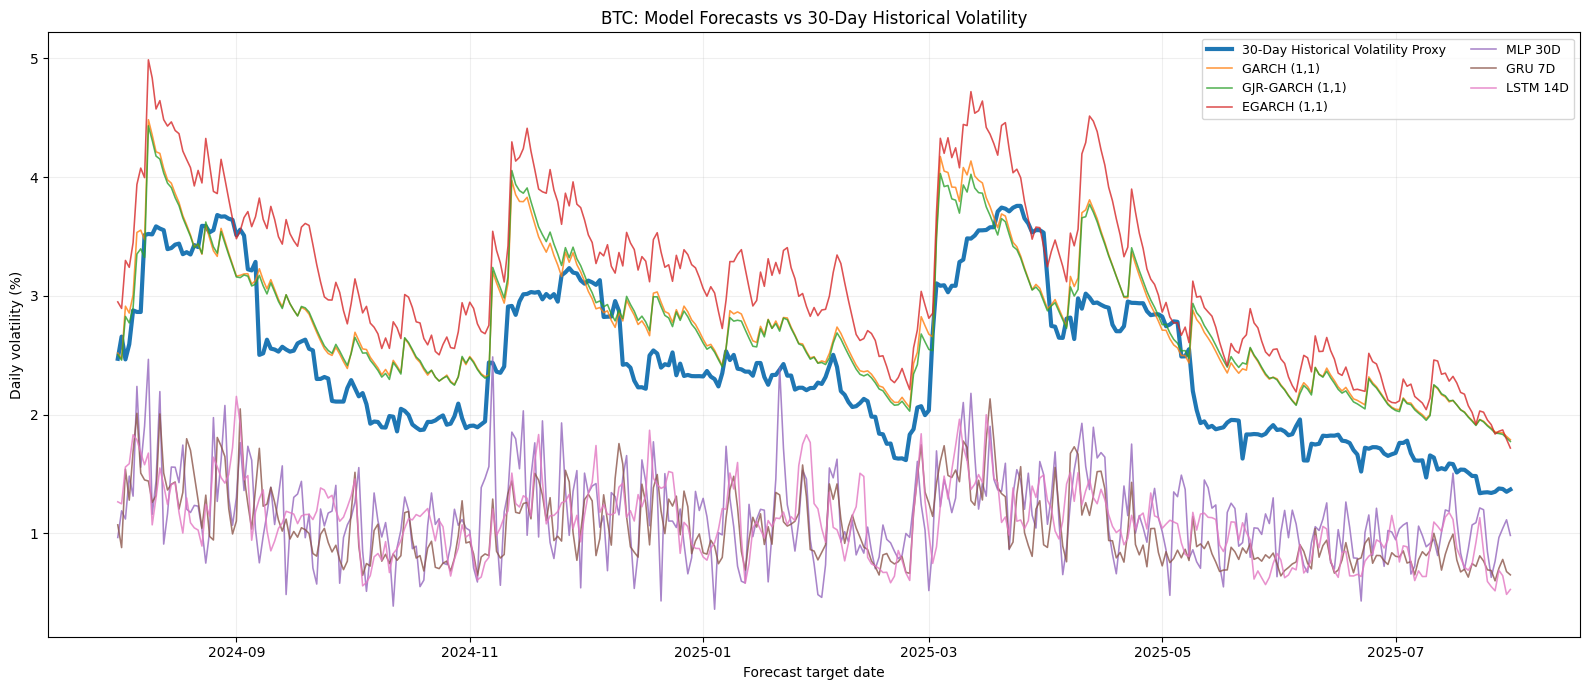

Saved: /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/figures/BTC_models_vs_rolling30_volatility.png


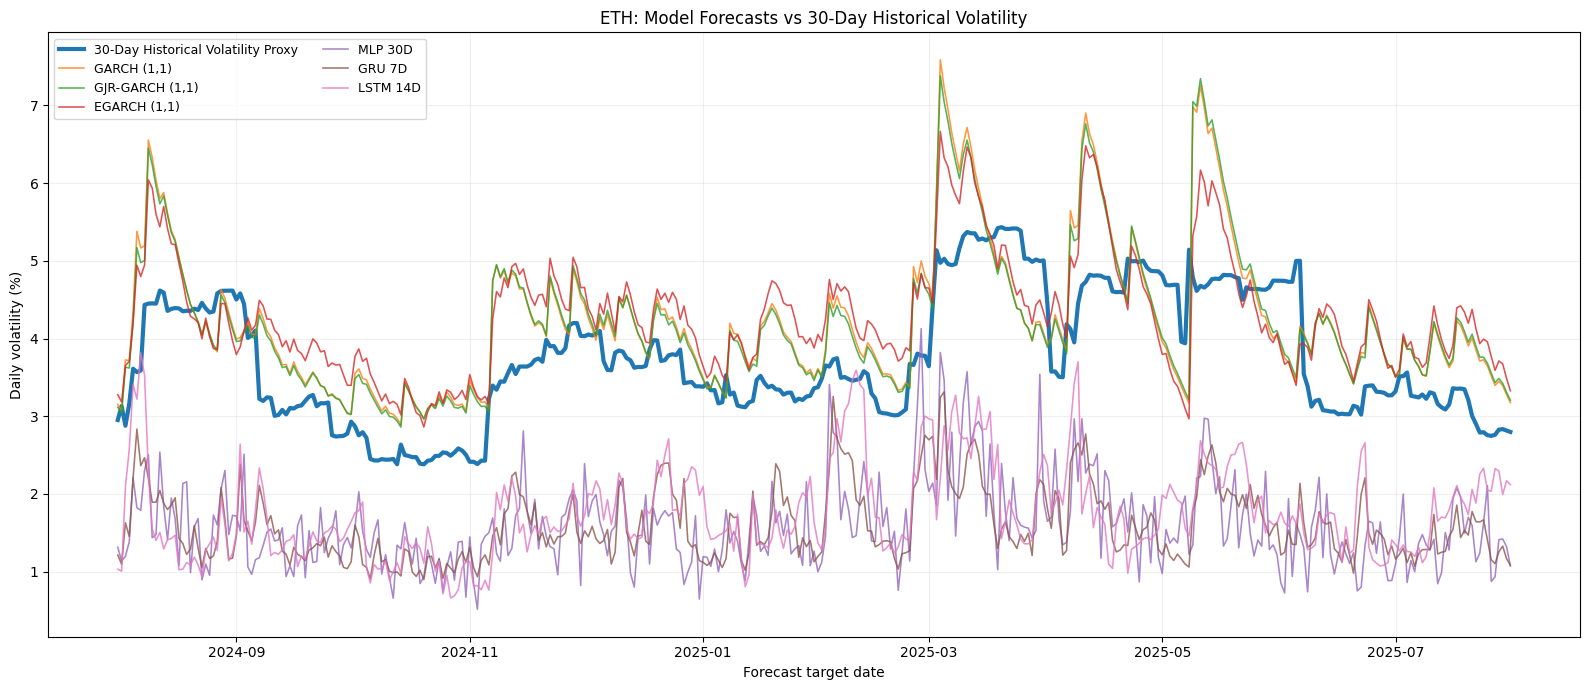

Saved: /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/figures/ETH_models_vs_rolling30_volatility.png


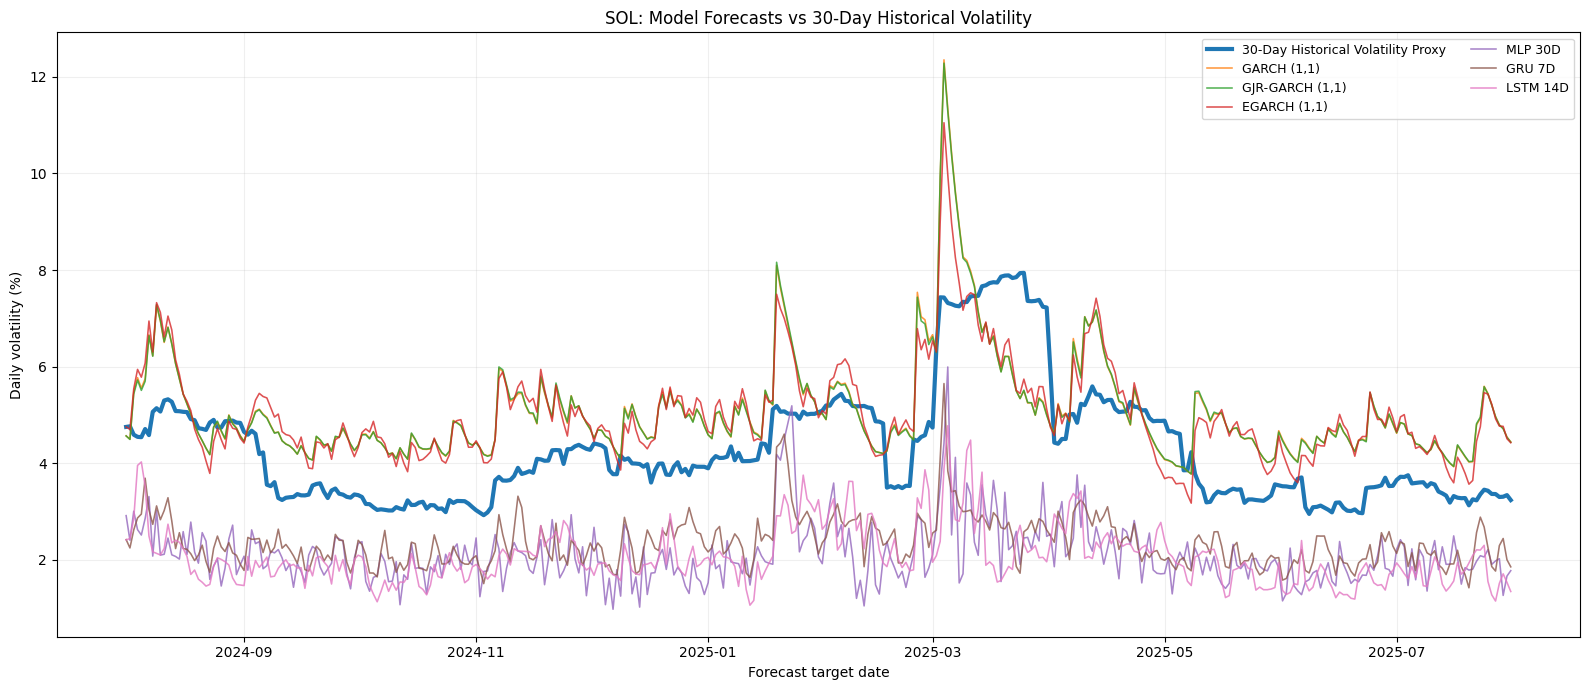

Saved: /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/figures/SOL_models_vs_rolling30_volatility.png


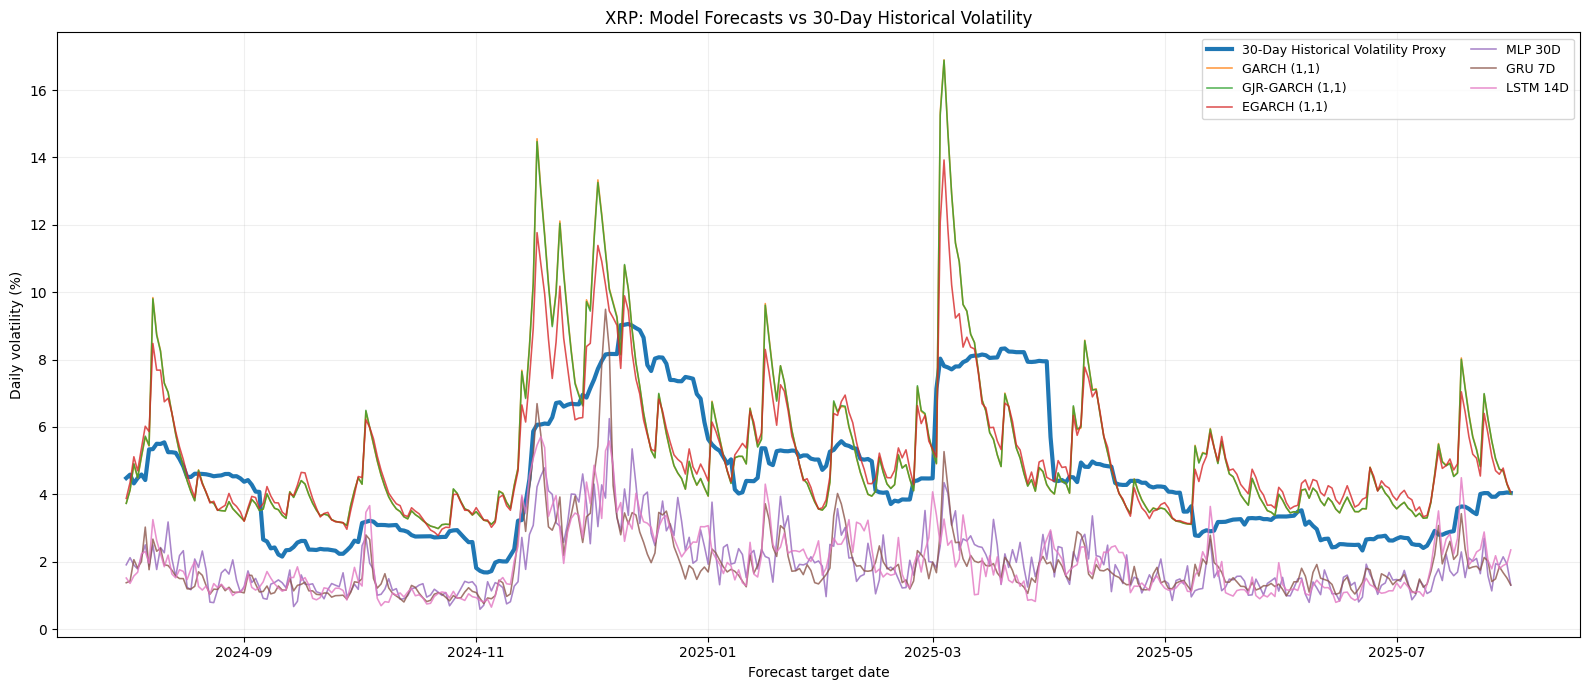

Saved: /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/figures/XRP_models_vs_rolling30_volatility.png


In [13]:
for symbol in ASSETS:

    asset_eval = (
        evaluation_df.loc[
            evaluation_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            [
                "target_date",
                "display_model",
            ]
        )
    )

    proxy_line = (
        asset_eval[
            [
                "target_date",
                "proxy_vol_pct",
            ]
        ]
        .drop_duplicates(
            "target_date"
        )
        .sort_values(
            "target_date"
        )
    )

    plt.figure(
        figsize=(
            16,
            7,
        )
    )

    plt.plot(
        proxy_line[
            "target_date"
        ],
        proxy_line[
            "proxy_vol_pct"
        ],
        label=(
            "30-Day Historical "
            "Volatility Proxy"
        ),
        linewidth=3.0,
    )

    for display_model in (
        MODEL_COLUMN_ORDER
    ):

        model_df = (
            asset_eval.loc[
                asset_eval[
                    "display_model"
                ].eq(
                    display_model
                )
            ]
            .sort_values(
                "target_date"
            )
        )

        if model_df.empty:
            raise ValueError(
                f"Missing {display_model} "
                f"for {symbol}."
            )

        plt.plot(
            model_df[
                "target_date"
            ],
            model_df[
                "pred_vol_pct"
            ],
            label=display_model,
            linewidth=1.15,
            alpha=0.80,
        )

    plt.xlabel(
        "Forecast target date"
    )

    plt.ylabel(
        "Daily volatility (%)"
    )

    plt.title(
        f"{ASSET_LABELS[symbol]}: "
        "Model Forecasts vs "
        "30-Day Historical Volatility"
    )

    plt.legend(
        ncol=2,
        fontsize=9,
    )

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            f"{ASSET_LABELS[symbol]}_"
            "models_vs_rolling30_volatility.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=240,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        figure_path,
    )

## 14. Final end-to-end QC

In [14]:
# Six models per asset.
assert (
    metrics_long_df
    .groupby("asset")[
        "display_model"
    ]
    .nunique()
    .eq(6)
    .all()
)

# Exactly four assets and six columns in each pivot.
for table_name, table in {
    "QLIKE": qlike_table,
    "RMSE": rmse_table,
    "MAE": mae_table,
}.items():

    assert (
        list(
            table.index
        )
        == [
            "BTC",
            "ETH",
            "SOL",
            "XRP",
        ]
    )

    assert (
        list(
            table.columns
        )
        == MODEL_COLUMN_ORDER
    )

    assert not table.isna().any().any()

    print(
        table_name,
        "pivot QC passed."
    )

# Exactly 365 observations for every model / asset.
assert (
    metrics_long_df[
        "n_observations"
    ]
    == 365
).all()

# Complete canonical validation date coverage.
assert (
    evaluation_df[
        "target_date"
    ].min()
    == VALIDATION_START
)

assert (
    evaluation_df[
        "target_date"
    ].max()
    == VALIDATION_END
)

# No duplicates.
assert not evaluation_df.duplicated(
    subset=[
        "symbol",
        "target_date",
        "model",
    ]
).any()

# Positive variances.
assert (
    evaluation_df[
        "pred_rv"
    ]
    > 0
).all()

assert (
    evaluation_df[
        "rolling30_var_proxy"
    ]
    > 0
).all()

# Finite metrics.
assert np.isfinite(
    metrics_long_df[
        [
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .to_numpy(
        dtype=float
    )
).all()

print(
    "\nALL FINAL QC CHECKS PASSED."
)

print(
    "\nMain outputs:"
)

for path in [
    QLIKE_TABLE_PATH,
    RMSE_TABLE_PATH,
    MAE_TABLE_PATH,
    LONG_METRICS_PATH,
    PREDICTIONS_PATH,
    RELATIONSHIP_PATH,
    FIGURE_DIR,
]:
    print(
        " -",
        path,
    )

QLIKE pivot QC passed.
RMSE pivot QC passed.
MAE pivot QC passed.

ALL FINAL QC CHECKS PASSED.

Main outputs:
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/QLIKE_table.csv
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/RMSE_table.csv
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/MAE_table.csv
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/all_model_metrics_long.csv
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/all_model_predictions_vs_proxy.parquet
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/rv_mean30_vs_rolling30_std_relationship.csv
 - /content/drive/MyDrive/Quant Research/results/ROLLING30_PROXY_EVALUATION_FINAL/figures


# Recommended paper interpretation

This analysis should be described as a **proxy-based robustness evaluation**.

Suggested wording:

> The one-day-ahead variance forecasts produced by the frozen ARCH-family and deep-learning models were additionally evaluated against 30-day historical volatility, measured as the trailing sample standard deviation of daily log returns. Model variance forecasts were square-rooted for graphical comparison and for MAE/RMSE, while QLIKE was evaluated on the variance scale using the squared historical-volatility proxy.

The 30-day historical-volatility proxy should not be described as identical to the earlier 30-Day Mean RV measure. The latter is a rolling mean of squared returns, whereas historical volatility is the sample standard deviation of returns around their rolling mean.